# Классификация пород кошек и собак по лицу

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [56]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2025-06-09 20:42:56--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Распознаётся www.soshnikov.com (www.soshnikov.com)… 79.137.227.122
Подключение к www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 24483412 (23M) [application/x-tar]
Сохранение в: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M  3.87MB/s    за 9.6s    

2025-06-09 20:43:06 (2.44 MB/s) - ‘petfaces.tar.gz’ сохранён [24483412/24483412]



Для визуализации списка изображений можно использовать такую функцию:

In [57]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

In [58]:
pip install optuna --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np
import optuna

## Кастомный DataLoader для классификации изображений животных

**Цель:** Реализовать гибкий загрузчик изображений для обучения свёрточных нейронных сетей (CNN) с автоматическим присвоением меток на основе структуры директорий.

**Задача:** Бинарная классификация (кошка/собака) на датасете из 36 пород с организацией данных в формате `root/{cat_,dog_}*/images`.

**Технические решения:**
- Парсинг меток из префиксов имён папок (`cat_*` → 0, `dog_*` → 1)
- Конвертация в RGB для защиты от изображений с альфа-каналом или в градациях серого
- Фильтрация по расширениям файлов для игнорирования системных артефактов


In [60]:
import os
from torchvision.datasets import DatasetFolder
from PIL import Image

class PetDataset(DatasetFolder):
    def __init__(self, root, transform=None):
        self.samples = []
        self.root = root
        self.transform = transform
        class_names = []
        for class_dir in os.listdir(root):
            class_path = os.path.join(root, class_dir)
            if not os.path.isdir(class_path):
                continue

            if class_dir.startswith("dog_"):
                label = 1  
            elif class_dir.startswith("cat_"):
                label = 0  
            else:
                continue  

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((img_path, label))

    def __getitem__(self, index):
        img_path, label = self.samples[index]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

    def __len__(self):
        return len(self.samples)

##  Кастомный Dataset для PyTorch

**Задача:** Создание гибкого интерфейса загрузки данных для обучения нейронных сетей с полным контролем над путями к файлам и метками.

**Ключевые особенности:**
*   **Гибкость:** Явная передача списков путей и меток позволяет легко реализовывать кастомные сплиты (train/val/test) без привязки к структуре папок.
*   **Предобработка:** Конвертация в RGB и поддержка пайплайна трансформаций (`torchvision.transforms`).
*   **Формат тензора:** Возврат метки в формате `float32`, что оптимально для задач бинарной классификации (BCELoss) или регрессии.

In [61]:
class PetDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

## Сбор и разделение данных

**Задача:** Автоматический сбор путей к изображениям и стратифицированное разделение на train/test.

**Особенности:**
*   **Лейблинг:** Парсинг меток из имен папок (`cat` → 0, `dog` → 1).
*   **Баланс:** `stratify=labels` сохраняет распределение классов в выборках.
*   **Повторяемость:** `random_state=42` фиксирует результат сплита.

In [62]:
def load_data(root_dir):
    image_paths = []
    labels = []

    for class_dir in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_dir)
        if os.path.isdir(class_path):
            label = 0 if class_dir.startswith('cat') else 1
            for img_file in os.listdir(class_path):
                img_path = os.path.join(class_path, img_file)
                image_paths.append(img_path)
                labels.append(label)

    return image_paths, labels

root_dir = 'petfaces'
image_paths, labels = load_data(root_dir)

X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [63]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [64]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Архитектура CNN для классификации изображений

**Задача:** Гибкая свёрточная сеть с настраиваемой глубиной для бинарной классификации.

**Особенности:**
*   **Масштабируемость:** Число слоёв и каналов задаётся параметрами (`conv_layers`, `fc_units`).
*   **Стабильность:** BatchNorm + ReLU + Dropout в каждом блоке для борьбы с переобучением.
*   **Адаптивность:** Автоматический расчёт размера fully-connected слоя под любое разрешение входа.

In [65]:
class PetClassifier(nn.Module):
    def __init__(self, conv_layers, fc_units, kernel_size):
        super().__init__()
        layers = []
        in_channels = 3

        for i in range(conv_layers):
            out_channels = 32 * (2**i)
            layers += [
                nn.Conv2d(in_channels, out_channels, kernel_size, padding='same'),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout(0.2)
            ]
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.fc = nn.Sequential(
            nn.Linear(out_channels * (128//(2**conv_layers))**2, fc_units),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(fc_units, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

## Оптимизация гиперпараметров модели

Автоматический подбор гиперпараметров CNN с использованием фреймворка Optuna.

- Поиск по пространству параметров: глубина сети, число нейронов, размер ядра, learning rate, batch size
- Early stopping: автоматическая остановка неперспективных испытаний через `trial.should_prune()`
- Валидация: оценка точности на тестовой выборке после каждой эпохи для объективного сравнения конфигураций

In [66]:
def objective(trial):
    conv_layers = trial.suggest_int('conv_layers', 2, 4)
    fc_units = trial.suggest_categorical('fc_units', [128, 256, 512])
    kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])

    train_dataset = PetDataset(X_train, y_train, train_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = PetClassifier(conv_layers, fc_units, kernel_size).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_dataset = PetDataset(X_test, y_test, test_transform)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                correct += (predicted.squeeze() == labels).sum().item()
                total += labels.size(0)

        accuracy = correct / total
        trial.report(accuracy, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return accuracy

In [67]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-06-09 20:43:08,611] A new study created in memory with name: no-name-4e68d26d-b3bd-401e-b4f7-8ad5b46a9911
[I 2025-06-09 20:44:04,700] Trial 0 finished with value: 0.6687402799377916 and parameters: {'conv_layers': 2, 'fc_units': 128, 'kernel_size': 5, 'lr': 0.0015652697867558597, 'batch_size': 64}. Best is trial 0 with value: 0.6687402799377916.
[I 2025-06-09 20:45:05,572] Trial 1 finished with value: 0.9471228615863142 and parameters: {'conv_layers': 4, 'fc_units': 128, 'kernel_size': 3, 'lr': 0.0001791908685863108, 'batch_size': 32}. Best is trial 1 with value: 0.9471228615863142.
[I 2025-06-09 20:45:57,474] Trial 2 finished with value: 0.9300155520995335 and parameters: {'conv_layers': 2, 'fc_units': 128, 'kernel_size': 3, 'lr': 0.0003389753091102099, 'batch_size': 32}. Best is trial 1 with value: 0.9471228615863142.
[I 2025-06-09 20:46:50,905] Trial 3 finished with value: 0.9486780715396579 and parameters: {'conv_layers': 4, 'fc_units': 256, 'kernel_size': 3, 'lr': 0.000572

In [68]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_params = study.best_params
print(f"Best hyperparameters: {best_params}")

Best hyperparameters: {'conv_layers': 4, 'fc_units': 256, 'kernel_size': 3, 'lr': 0.0005727071759680213, 'batch_size': 32}


In [69]:
final_model = PetClassifier(
    conv_layers=best_params['conv_layers'],
    fc_units=best_params['fc_units'],
    kernel_size=best_params['kernel_size']
).to(device)

In [70]:
from tqdm import trange

In [71]:
train_val_dataset = PetDataset(X_train + X_test, y_train + y_test, train_transform)
train_loader = DataLoader(train_val_dataset, batch_size=best_params['batch_size'], shuffle=True)

optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])
criterion = nn.BCEWithLogitsLoss()

for epoch in trange(20):
    final_model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()

100%|██████████| 20/20 [01:55<00:00,  5.79s/it]


In [72]:
test_dataset = PetDataset(X_test, y_test, test_transform)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])

final_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted.squeeze() == labels).sum().item()
        total += labels.size(0)

print(f"Final Test Accuracy: {correct/total:.4f}")

Final Test Accuracy: 0.9751


## Оценка качества модели

Функция комплексной оценки модели бинарной классификации на тестовой выборке.

- Визуализация: матрица ошибок (confusion matrix) с аннотациями для анализа типов ошибок
- Метрики: полный отчёт (precision, recall, f1-score) по каждому классу через `classification_report`
- Интерпретируемость: вывод топ-3 наиболее уверенных правильных предсказаний и ошибок для качественного анализа

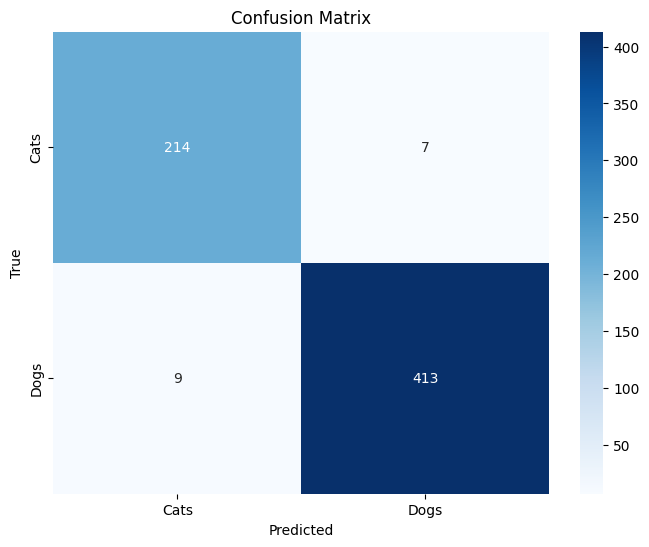

              precision    recall  f1-score   support

        Cats       0.96      0.97      0.96       221
        Dogs       0.98      0.98      0.98       422

    accuracy                           0.98       643
   macro avg       0.97      0.97      0.97       643
weighted avg       0.98      0.98      0.98       643


Top-3 уверенных правильных предсказаний:
     true  pred  prob
8       1     1   1.0
71      1     1   1.0
144     1     1   1.0

Top-3 уверенных ошибок:
     true  pred      prob
10      0     1  0.995845
421     0     1  0.828391
271     0     1  0.652002


In [73]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_preds.extend(preds.squeeze())
            all_probs.extend(probs.squeeze())
            all_labels.extend(labels.cpu().numpy().astype(int))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cats', 'Dogs'],
                yticklabels=['Cats', 'Dogs'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=['Cats', 'Dogs']))

    df = pd.DataFrame({'true': all_labels, 'pred': all_preds, 'prob': all_probs})

    top3_correct = df[df['true'] == df['pred']].nlargest(3, 'prob')
    print("\nTop-3 уверенных правильных предсказаний:")
    print(top3_correct)

    top3_errors = df[df['true'] != df['pred']].nlargest(3, 'prob')
    print("\nTop-3 уверенных ошибок:")
    print(top3_errors)

evaluate_model(final_model, test_loader)

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import optuna
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

In [75]:
device = torch.device('cuda')

## Загрузка и валидация датасета

Универсальная функция для сбора путей к изображениям и меткам классов с проверкой целостности данных.

- Поддержка мультиклассовой классификации: автоматическое построение словаря `class_to_idx`
- Валидация: проверка на наличие файлов в директориях и исключение пустых датасетов
- Статистика: вывод распределения классов для анализа баланса перед обучением

In [76]:
def load_data(root_dir):
    classes = sorted([d for d in os.listdir(root_dir)
                    if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    image_paths = []
    labels = []
    label_counts = Counter()

    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        files = [f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f)) and
                f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not files:
            print(f"Warning: No images found in {class_dir}")
            continue

        label_counts[class_name] = len(files)
        for img_file in files:
            img_path = os.path.join(class_dir, img_file)
            image_paths.append(img_path)
            labels.append(class_to_idx[class_name])

    if not image_paths:
        raise ValueError("No images found in dataset directory")

    print(f"Loaded {len(image_paths)} images from {len(classes)} classes")
    print("Class distribution:", label_counts)

    return image_paths, labels, classes, class_to_idx, label_counts

In [77]:
root_dir = 'petfaces'
image_paths, labels, classes, class_to_idx, label_counts = load_data(root_dir)
num_classes = len(classes)

Loaded 3211 images from 35 classes
Class distribution: Counter({'dog_english': 182, 'dog_american': 174, 'cat_British': 100, 'cat_Siamese': 100, 'cat_Sphynx': 100, 'cat_Birman': 98, 'dog_newfoundland': 98, 'cat_Russian': 97, 'cat_Ragdoll': 96, 'cat_Maine': 95, 'dog_leonberger': 95, 'cat_Persian': 94, 'dog_havanese': 93, 'cat_Abyssinian': 92, 'dog_great': 91, 'dog_wheaten': 91, 'dog_pomeranian': 90, 'dog_saint': 90, 'dog_pug': 89, 'dog_basset': 88, 'cat_Bombay': 87, 'dog_staffordshire': 87, 'dog_boxer': 85, 'dog_chihuahua': 83, 'dog_keeshond': 83, 'dog_shiba': 82, 'dog_yorkshire': 81, 'dog_beagle': 78, 'dog_miniature': 75, 'cat_Bengal': 74, 'dog_japanese': 74, 'cat_Egyptian': 73, 'dog_german': 69, 'dog_samoyed': 68, 'dog_scottish': 59})


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [79]:
train_labels = np.array(y_train)
train_class_counts = np.bincount(train_labels)
class_weights = 1.0 / (torch.Tensor(train_class_counts) + 1e-6)
samples_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(X_train),
    replacement=True
)

In [80]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
class PetDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        assert len(image_paths) == len(labels), f"Mismatch: {len(image_paths)} vs {len(labels)}"
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if idx < 0 or idx >= len(self):
            raise IndexError(f"Invalid index {idx} for dataset size {len(self)}")

        img_path = self.image_paths[idx]
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

## Архитектура кастомной свёрточной сети

Гибкая CNN для мультиклассовой классификации изображений с настраиваемой глубиной и регуляризацией.

- Конфигурируемость: число свёрточных слоёв, размер ядра, число нейронов в FC-слое и dropout задаются параметрами
- Стабильность обучения: BatchNorm и Dropout в каждом блоке для снижения переобучения
- Универсальность: AdaptiveAvgPool2d обеспечивает работу с изображениями произвольного разрешения
- Масштабирование каналов: удвоение числа фильтров на каждом уровне (64 → 128 → 256)

In [82]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes, conv_layers=3, fc_units=512, dropout=0.5, kernel_size=3):
        super().__init__()
        self.features = nn.Sequential()
        in_channels = 3

        for i in range(conv_layers):
            out_channels = 64 * (2**i)
            self.features.add_module(f'conv{i}', nn.Conv2d(
                in_channels, out_channels,
                kernel_size=kernel_size,
                padding=kernel_size//2
            ))
            self.features.add_module(f'bn{i}', nn.BatchNorm2d(out_channels))
            self.features.add_module(f'relu{i}', nn.ReLU())
            self.features.add_module(f'pool{i}', nn.MaxPool2d(2))
            self.features.add_module(f'dropout{i}', nn.Dropout2d(dropout))
            in_channels = out_channels

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(in_channels, fc_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_units, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Оптимизация гиперпараметров CNN через Optuna

Функция цели для автоматического подбора параметров модели и процесса обучения.

- Разделение пространства поиска: отдельные словари для архитектуры модели (`conv_layers`, `dropout`) и параметров обучения (`lr`, `batch_size`)
- Работа с дисбалансом классов: использование взвешенной функции потерь `CrossEntropyLoss(weight=class_weights)`
- Early pruning: остановка неперспективных испытаний через `trial.should_prune()` для экономии вычислительных ресурсов
- Логирование: сохранение истории потерь и точности в атрибуты испытания для последующего анализа
- Стратифицированная выборка: использование `sampler` для поддержания баланса классов в каждом батче

In [83]:
def objective(trial):
    model_params = {
        'conv_layers': trial.suggest_int('conv_layers', 2, 4),
        'fc_units': trial.suggest_categorical('fc_units', [256, 512, 1024]),
        'dropout': trial.suggest_float('dropout', 0.2, 0.5),
        'kernel_size': trial.suggest_categorical('kernel_size', [3, 5])
    }

    training_params = {
        'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64])
    }

    model = CustomCNN(num_classes, **model_params).to(device)
    optimizer = optim.Adam(model.parameters(), lr=training_params['lr'])
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

    train_dataset = PetDataset(X_train, y_train, train_transform)
    train_loader = DataLoader(
        train_dataset,
        batch_size=training_params['batch_size'],
        sampler=sampler
    )

    train_losses = []
    val_accuracies = []
    best_acc = 0

    for epoch in range(15):
        model.train()
        epoch_loss = 0
        progress = tqdm(train_loader, desc=f'Trial {trial.number} Epoch {epoch+1}', leave=False)

        for images, labels in progress:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress.set_postfix({'loss': epoch_loss/(progress.n+1)})

        model.eval()
        val_dataset = PetDataset(X_test, y_test, test_transform)
        val_loader = DataLoader(val_dataset, batch_size=training_params['batch_size'])

        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        val_accuracies.append(val_acc)
        train_losses.append(epoch_loss/len(train_loader))

        trial.report(val_acc, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_acc > best_acc:
            best_acc = val_acc

    trial.set_user_attr('train_losses', train_losses)
    trial.set_user_attr('val_accuracies', val_accuracies)

    return best_acc

In [84]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-06-09 20:53:38,070] A new study created in memory with name: no-name-acc75ca4-e980-4cf8-a97c-dcae8302e268
[I 2025-06-09 20:56:47,800] Trial 0 finished with value: 0.11353032659409021 and parameters: {'conv_layers': 4, 'fc_units': 1024, 'dropout': 0.39164020103914976, 'kernel_size': 3, 'lr': 0.00010461832163868828, 'batch_size': 64}. Best is trial 0 with value: 0.11353032659409021.
[I 2025-06-09 20:59:39,571] Trial 1 finished with value: 0.14774494556765164 and parameters: {'conv_layers': 3, 'fc_units': 1024, 'dropout': 0.2901371631458566, 'kernel_size': 3, 'lr': 0.0014958086617927304, 'batch_size': 32}. Best is trial 1 with value: 0.14774494556765164.
[I 2025-06-09 21:03:32,680] Trial 2 finished with value: 0.16018662519440124 and parameters: {'conv_layers': 4, 'fc_units': 1024, 'dropout': 0.42221403209373554, 'kernel_size': 5, 'lr': 0.00038708683504847923, 'batch_size': 64}. Best is trial 2 with value: 0.16018662519440124.
[I 2025-06-09 21:07:01,510] Trial 3 finished with valu

In [86]:
best_params = study.best_params
print(f"Best parameters: {best_params}")

Best parameters: {'conv_layers': 4, 'fc_units': 512, 'dropout': 0.24628424081436529, 'kernel_size': 3, 'lr': 0.0010438492856446678, 'batch_size': 64}


In [87]:
model_params = {
    k: v for k, v in best_params.items()
    if k in ['conv_layers', 'fc_units', 'dropout', 'kernel_size']
}
training_params = {
    k: v for k, v in best_params.items()
    if k in ['lr', 'batch_size']
}

final_model = CustomCNN(num_classes, **model_params).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=training_params['lr'])
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [88]:
full_dataset = PetDataset(X_train + X_test, y_train + y_test, train_transform)
train_loader = DataLoader(
    full_dataset,
    batch_size=training_params['batch_size'],
    sampler=sampler
)

In [89]:
train_loss_history = []
val_acc_history = []

In [90]:
for epoch in range(40):
    final_model.train()
    epoch_loss = 0
    progress = tqdm(train_loader, desc=f'Epoch {epoch+1}/40')

    for images, labels in progress:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix({'loss': epoch_loss/(progress.n+1)})

    train_loss_history.append(epoch_loss/len(train_loader))

    final_model.eval()
    val_dataset = PetDataset(X_test, y_test, test_transform)
    val_loader = DataLoader(val_dataset, batch_size=training_params['batch_size'])

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = final_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={train_loss_history[-1]:.4f}, Val Acc={val_acc:.4f}")

Epoch 1/40: 100%|██████████| 41/41 [00:11<00:00,  3.50it/s, loss=3.39]


Epoch 1: Loss=3.3940, Val Acc=0.0684


Epoch 2/40: 100%|██████████| 41/41 [00:12<00:00,  3.24it/s, loss=3.17]


Epoch 2: Loss=3.1742, Val Acc=0.0918


Epoch 3/40: 100%|██████████| 41/41 [00:12<00:00,  3.41it/s, loss=3.14]


...

Epoch 38: Loss=2.3647, Val Acc=0.3048


Epoch 39/40: 100%|██████████| 41/41 [00:12<00:00,  3.25it/s, loss=2.37]


Epoch 39: Loss=2.3704, Val Acc=0.3344


Epoch 40/40: 100%|██████████| 41/41 [00:12<00:00,  3.33it/s, loss=2.32]


Epoch 40: Loss=2.3161, Val Acc=0.3204


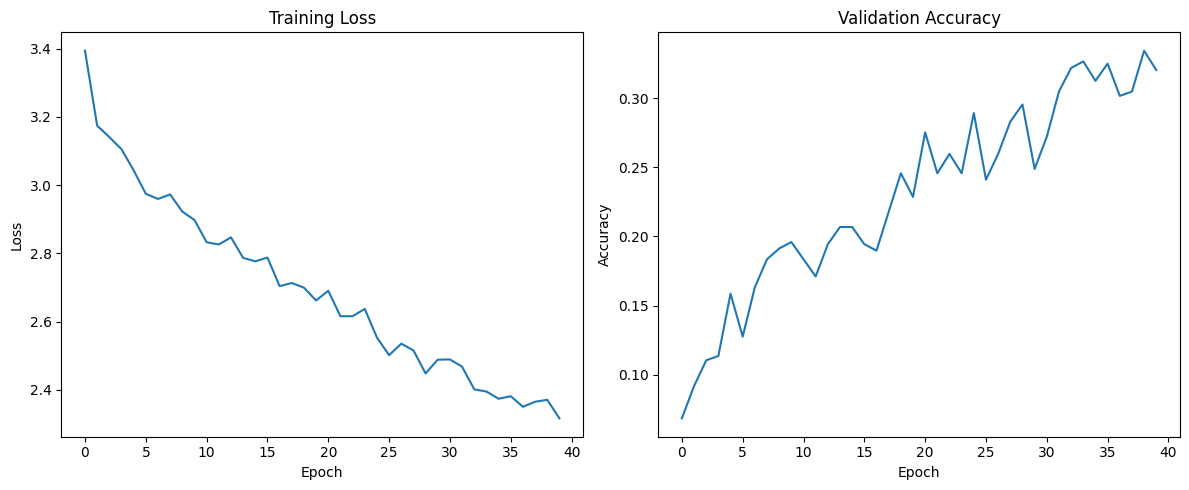

In [91]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## Оценка модели мультиклассовой классификации

Функция комплексной оценки модели на тестовой выборке.

- Визуализация: матрица ошибок с подписями классов для анализа путаницы между категориями
- Метрики: отчёт precision/recall/f1-score по каждому классу через `classification_report`
- Top-k точность: расчёт Top-1 и Top-3 accuracy для оценки качества ранжирования предсказаний
- Вероятностный анализ: использование `softmax` для получения распределения вероятностей по классам

In [92]:
def evaluate_model(model, test_loader, classes):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=classes))

    top3_correct = 0
    for i in range(len(all_labels)):
        if all_labels[i] in torch.topk(all_probs[i], 3).indices:
            top3_correct += 1

    print(f"\nTop-1 Accuracy: {100 * (all_preds == all_labels).float().mean():.2f}%")
    print(f"Top-3 Accuracy: {100 * top3_correct / len(all_labels):.2f}%")

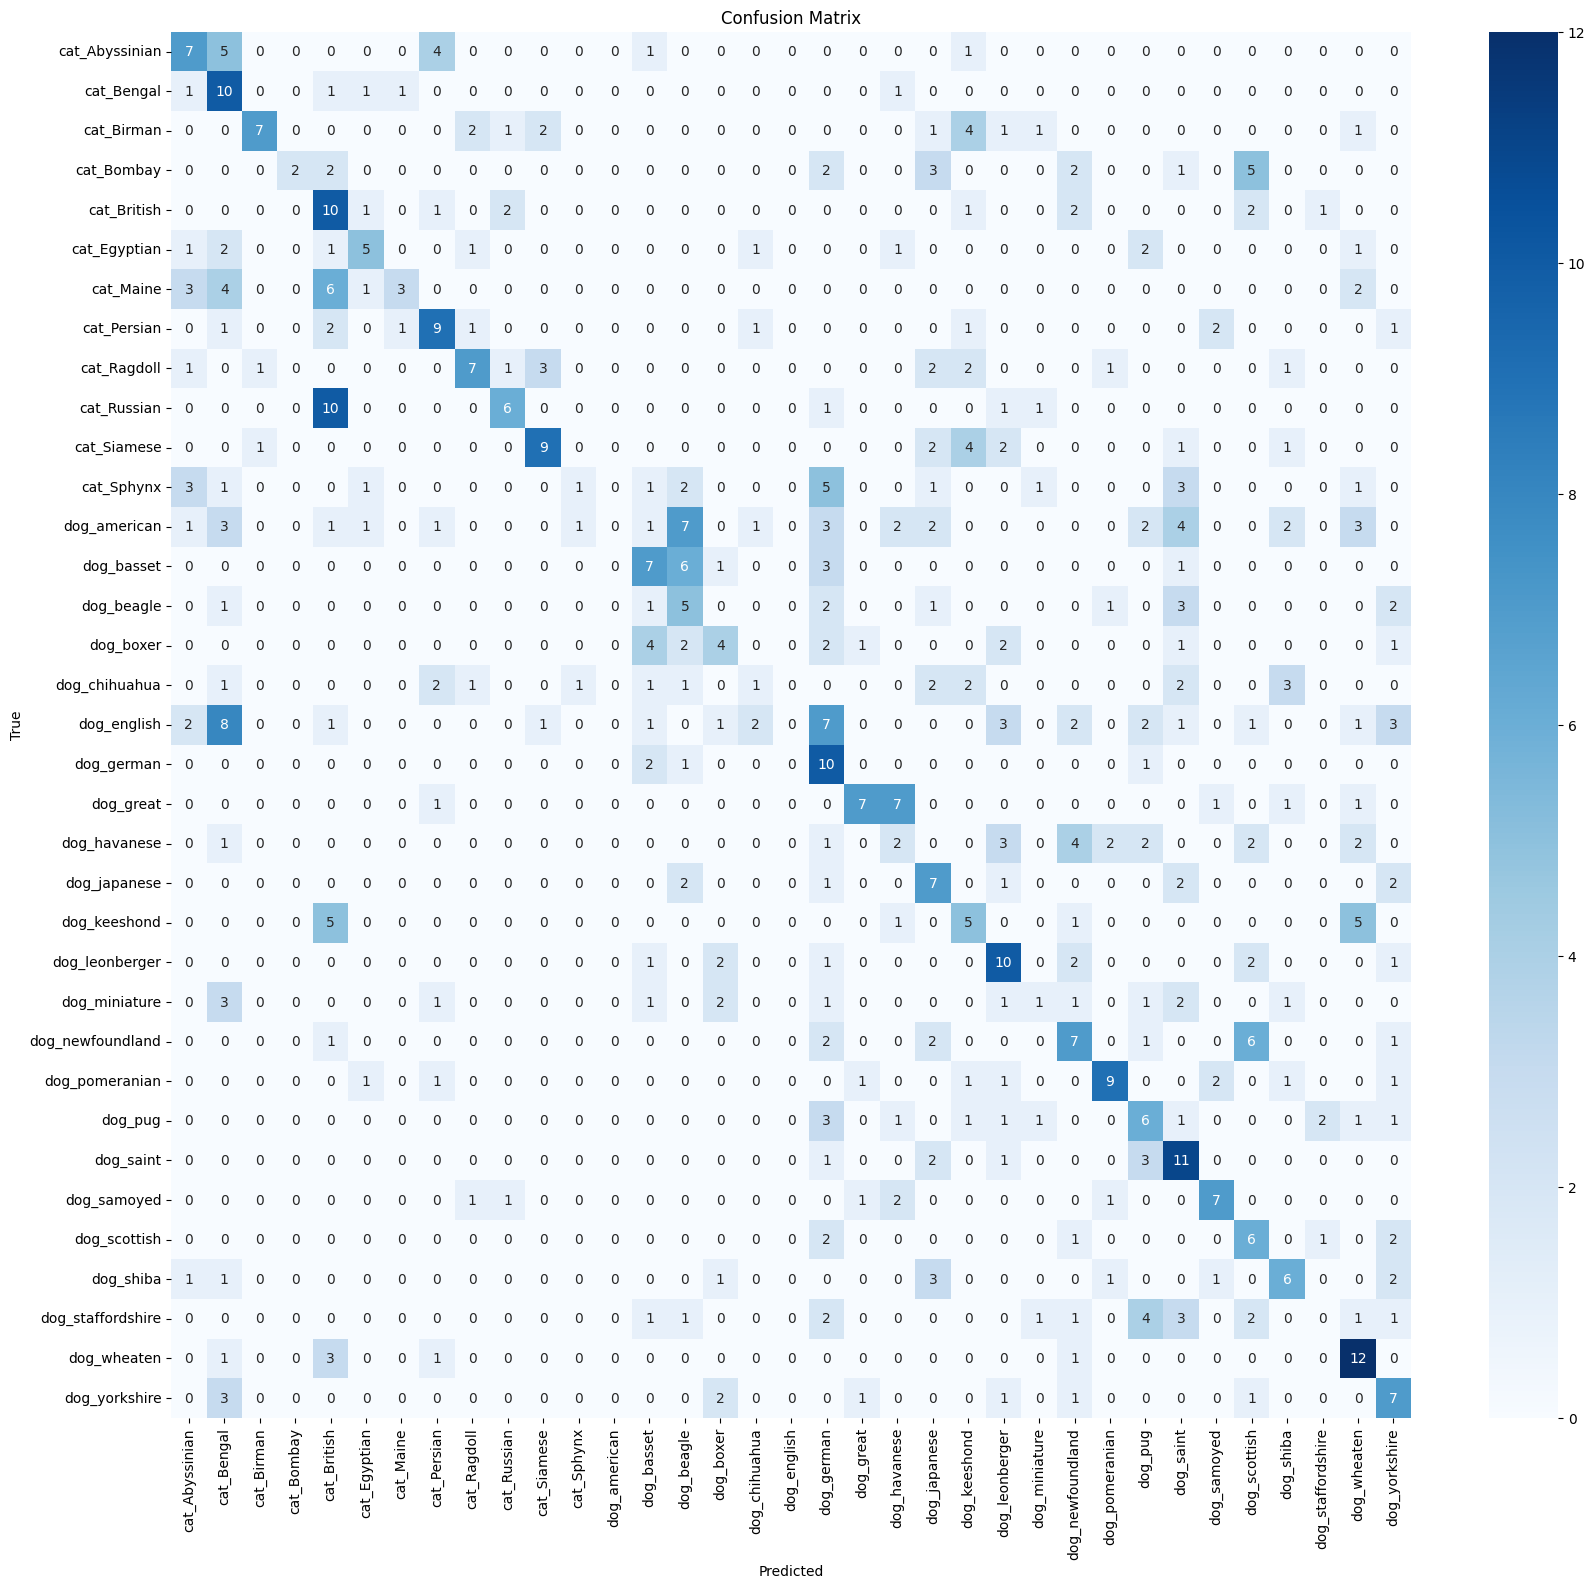

                   precision    recall  f1-score   support

   cat_Abyssinian       0.35      0.39      0.37        18
       cat_Bengal       0.22      0.67      0.33        15
       cat_Birman       0.78      0.35      0.48        20
       cat_Bombay       1.00      0.12      0.21        17
      cat_British       0.23      0.50      0.32        20
     cat_Egyptian       0.45      0.33      0.38        15
        cat_Maine       0.60      0.16      0.25        19
      cat_Persian       0.43      0.47      0.45        19
      cat_Ragdoll       0.54      0.37      0.44        19
      cat_Russian       0.55      0.32      0.40        19
      cat_Siamese       0.60      0.45      0.51        20
       cat_Sphynx       0.33      0.05      0.09        20
     dog_american       0.00      0.00      0.00        35
       dog_basset       0.32      0.39      0.35        18
       dog_beagle       0.19      0.31      0.23        16
        dog_boxer       0.31      0.24      0.27       

/home/den/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/den/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/den/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [93]:
test_dataset = PetDataset(X_test, y_test, test_transform)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])
evaluate_model(final_model, test_loader, classes)